In [44]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import os

def make_depth_unique(temp, depth_coord):
    """
    temp: DataArray TEMP with dim IDX_TEMP
    depth_coord: ds["NOMINAL_DEPTH_TEMP"].values
    """
    temp = temp.assign_coords(depth=("IDX_TEMP", depth_coord))
    temp = temp.swap_dims({"IDX_TEMP": "depth"})
    temp = temp.groupby("depth").mean("depth", skipna=True).sortby("depth")
    return temp

def wrap_lon(lon_value, lon_coord):
    lonmin = float(lon_coord.min())
    lonmax = float(lon_coord.max())
    if lonmax > 180 and lon_value < 0:
        return lon_value + 360
    if lonmax <= 180 and lon_value > 180:
        return lon_value - 360
    return lon_value


Part A — OBS (SOTS 2023–2024)

In [45]:
fname_obs = "/scratch/fy29/yw5715/obs mld data/IMOS_DWM-SOTS_BCMOPSTUW_20230517_SOFS_FV02_SOFS-12-2023-hourly-gridded-product_END-20240406_C-20240629.nc"
ds_obs = xr.open_dataset(fname_obs)

# TEMP(depth, TIME) + unique depth
temp_obs = make_depth_unique(ds_obs["TEMP"], ds_obs["NOMINAL_DEPTH_TEMP"].values)

# Local time (UTC+10)
time_lt_obs = temp_obs["TIME"] + np.timedelta64(10, "h")
hour_lt_obs = time_lt_obs.dt.hour

# day/night windows
is_day_obs   = (hour_lt_obs >= 12) & (hour_lt_obs <= 16)
is_night_obs = (hour_lt_obs >= 2)  & (hour_lt_obs <= 5)

# local day id
day_id_obs = time_lt_obs.dt.floor("D")  # group key

# daily mean profiles (day/night)
td_obs = temp_obs.where(is_day_obs).groupby(day_id_obs).mean("TIME", skipna=True)
tn_obs = temp_obs.where(is_night_obs).groupby(day_id_obs).mean("TIME", skipna=True)

# keep 0–50 m for plots
td50_obs = td_obs.sel(depth=slice(0, 50))
tn50_obs = tn_obs.sel(depth=slice(0, 50))

# dT profile (day-night) for 0–50m
dTprof_obs = (td50_obs - tn50_obs)

# ---- ΔT daily index: T(0–5m) - T(10m) using DAYTIME mean profiles (matches your later thresholds)
day_dim_obs = [d for d in td_obs.dims if d != "depth"][0]
day_time_obs = td_obs[day_dim_obs].astype("datetime64[ns]")

T0_5_obs = td_obs.sel(depth=slice(0,5)).mean("depth", skipna=True)
T10_obs  = td_obs.sel(depth=10, method="nearest")
dT_obs = (T0_5_obs - T10_obs).rename("dT_0_5_minus_10m")

# make dT into TIME series (daily)
dT_obs_ts = dT_obs.assign_coords(TIME=day_time_obs).swap_dims({day_dim_obs: "TIME"}).sortby("TIME")

# DWL flag used in your plots
DWL_flag_obs = (dT_obs_ts > 0.2).rename("DWL_flag")


Fig 1: SOTS 2023–2024 Day vs Night Temperature Profiles

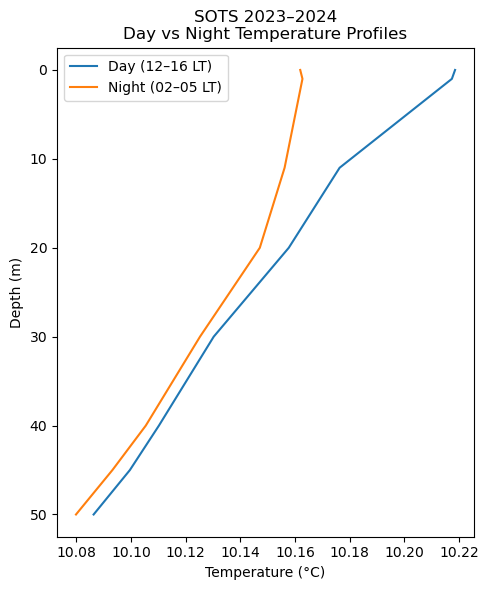

In [46]:
plt.figure(figsize=(5,6))
td50_obs.mean(dim=day_dim_obs).plot(y="depth", label="Day (12–16 LT)")
tn50_obs.mean(dim=day_dim_obs).plot(y="depth", label="Night (02–05 LT)")
plt.gca().invert_yaxis()
plt.xlabel("Temperature (°C)")
plt.ylabel("Depth (m)")
plt.title("SOTS 2023–2024\nDay vs Night Temperature Profiles")
plt.legend()
plt.tight_layout()
plt.show()


Fig 2: Mean Day–Night ΔT (12–16 − 02–05 LT)

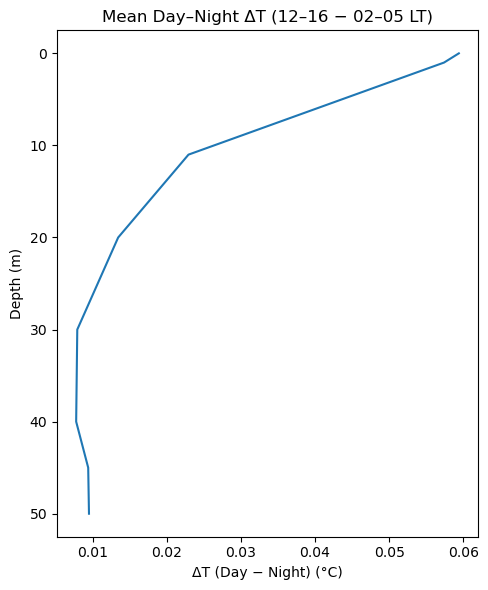

In [47]:
plt.figure(figsize=(5,6))
dTprof_obs.mean(dim=day_dim_obs).plot(y="depth")
plt.gca().invert_yaxis()
plt.xlabel("ΔT (Day − Night) (°C)")
plt.ylabel("Depth (m)")
plt.title("Mean Day–Night ΔT (12–16 − 02–05 LT)")
plt.tight_layout()
plt.show()


Fig 3: Monthly DWL occurrence (ΔT threshold method)

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

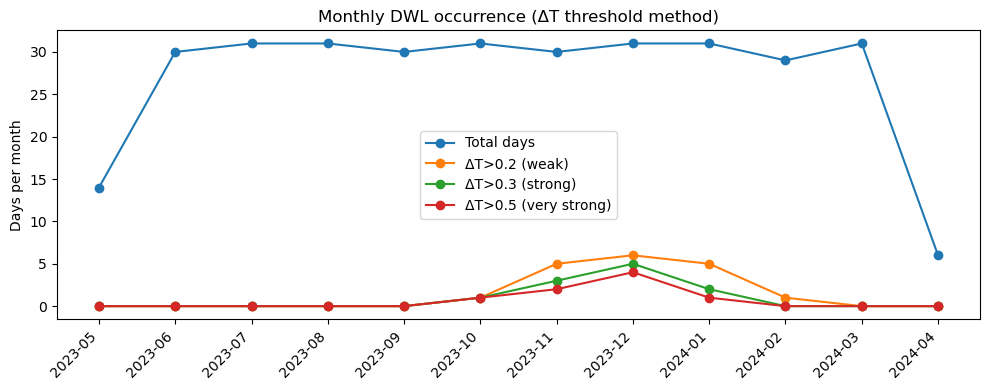

In [48]:
month_id_obs = dT_obs_ts["TIME"].dt.strftime("%Y-%m").rename("month")

flag02 = (dT_obs_ts > 0.2)
flag03 = (dT_obs_ts > 0.3)
flag05 = (dT_obs_ts > 0.5)

total_days = dT_obs_ts.groupby(month_id_obs).count()
days02 = flag02.groupby(month_id_obs).sum()
days03 = flag03.groupby(month_id_obs).sum()
days05 = flag05.groupby(month_id_obs).sum()

months = total_days["month"].values

plt.figure(figsize=(10,4))
plt.plot(months, total_days.values, marker="o", label="Total days")
plt.plot(months, days02.values, marker="o", label="ΔT>0.2 (weak)")
plt.plot(months, days03.values, marker="o", label="ΔT>0.3 (strong)")
plt.plot(months, days05.values, marker="o", label="ΔT>0.5 (very strong)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Days per month")
plt.title("Monthly DWL occurrence (ΔT threshold method)")
plt.legend()
plt.tight_layout()
plt.show()


Fig 4: SOTS wind speed (UWIND/VWIND) — hourly

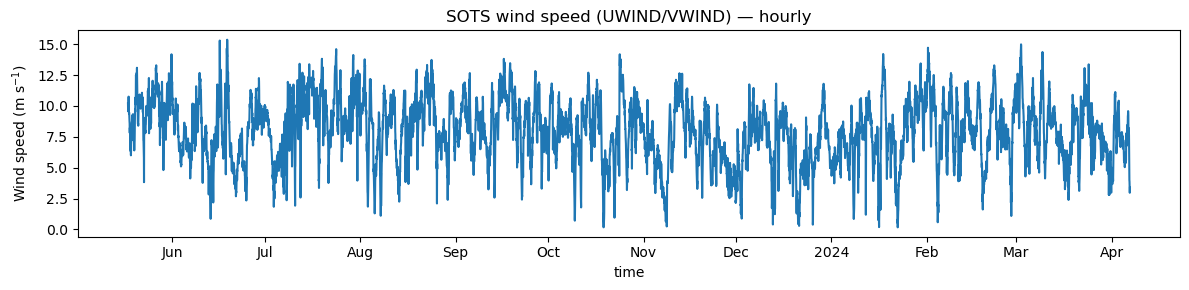

In [49]:
u = ds_obs["UWIND"]
v = ds_obs["VWIND"]

if "IDX_UWIND" in u.dims: u = u.isel(IDX_UWIND=0)
if "IDX_VWIND" in v.dims: v = v.isel(IDX_VWIND=0)

wspd = np.sqrt(u**2 + v**2).rename("WSPD")

plt.figure(figsize=(12,3))
wspd.plot()
plt.ylabel("Wind speed (m s$^{-1}$)")
plt.title("SOTS wind speed (UWIND/VWIND) — hourly")
plt.tight_layout()
plt.show()


Figure 5: DWL strength vs wind speed at SOTS

N matched days: 325


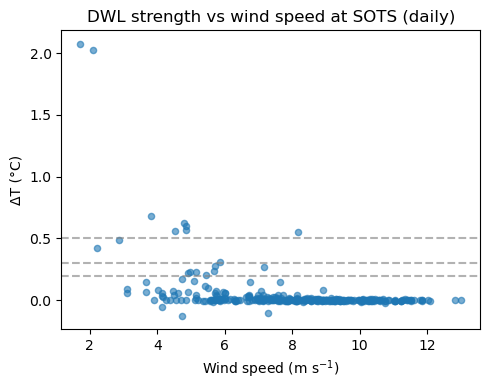

In [50]:
# Align ΔT and wind speed on common daily dates
dT_a, w_a = xr.align(dT_obs_ts, wspd_daily, join="inner")

mask = np.isfinite(dT_a.values) & np.isfinite(w_a.values)

print("N matched days:", mask.sum())

# Scatter plot: DWL strength vs wind speed
plt.figure(figsize=(5,4))

plt.scatter(
    w_a.values[mask],
    dT_a.values[mask],
    s=20,
    alpha=0.6
)

# ΔT thresholds
plt.axhline(0.2, linestyle="--", color="gray", alpha=0.6)
plt.axhline(0.3, linestyle="--", color="gray", alpha=0.6)
plt.axhline(0.5, linestyle="--", color="gray", alpha=0.6)

plt.xlabel("Wind speed (m s$^{-1}$)")
plt.ylabel("ΔT (°C)")
plt.title("DWL strength vs wind speed at SOTS (daily)")

plt.tight_layout()
plt.show()


Fig 6: Wind speed distribution — DWL vs non-DWL days

<Figure size 450x450 with 0 Axes>

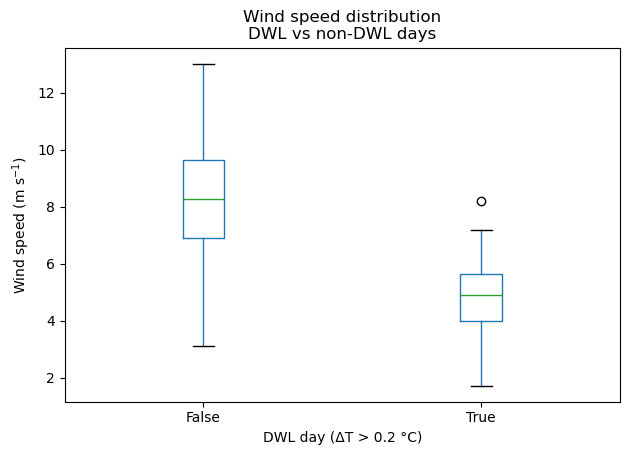

In [51]:
# boolean on daily time axis
DWL_a, W_a = xr.align(DWL_flag_obs, wspd_daily, join="inner")
mask = np.isfinite(W_a.values) & np.isfinite(DWL_a.values)

df_w = pd.DataFrame({
    "wind": W_a.values[mask],
    "DWL":  DWL_a.values[mask].astype(bool)
})

plt.figure(figsize=(4.5,4.5))
df_w.boxplot(column="wind", by="DWL", grid=False)
plt.ylabel("Wind speed (m s$^{-1}$)")
plt.xlabel("DWL day (ΔT > 0.2 °C)")
plt.title("Wind speed distribution\nDWL vs non-DWL days")
plt.suptitle("")
plt.tight_layout()
plt.show()



Fig 7: SOTS SW_day: mean SW over 12–16 LT (UTC+10)

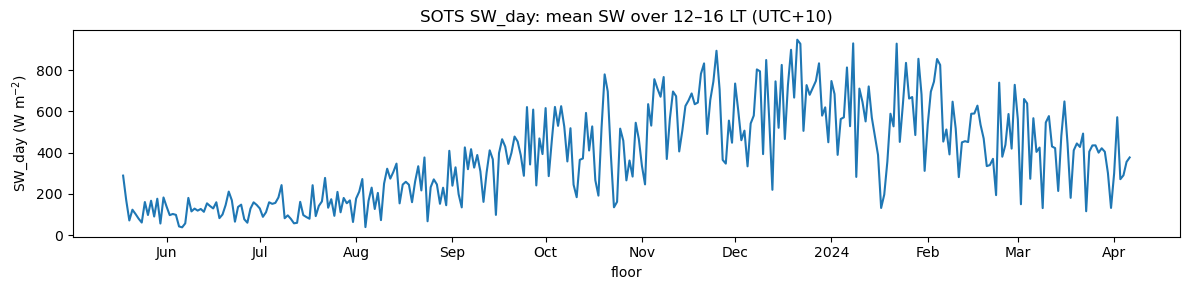

In [52]:
sw = ds_obs["SW"]
if "IDX_SW" in sw.dims:
    sw = sw.isel(IDX_SW=0)

sw_lt = sw.assign_coords(TIME=sw["TIME"] + np.timedelta64(10, "h"))
hour_lt = sw_lt["TIME"].dt.hour
is_day = (hour_lt >= 12) & (hour_lt <= 16)
day_id = sw_lt["TIME"].dt.floor("D")

SW_day = sw_lt.where(is_day).groupby(day_id).mean("TIME", skipna=True).rename("SW_day_12_16LT")

plt.figure(figsize=(12,3))
SW_day.plot()
plt.ylabel("SW_day (W m$^{-2}$)")
plt.title("SOTS SW_day: mean SW over 12–16 LT (UTC+10)")
plt.tight_layout()
plt.show()


Fig 8: DWL strength vs SW_day

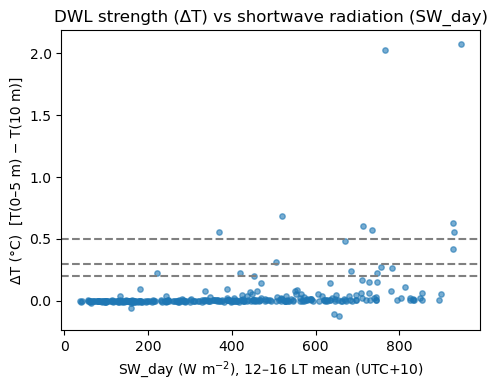

In [53]:
# --- SW_day (12–16 LT mean, UTC+10) ---
sw = ds_obs["SW"]
if "IDX_SW" in sw.dims:
    sw = sw.isel(IDX_SW=0)

sw_lt  = sw.assign_coords(TIME=sw.TIME + np.timedelta64(10, "h"))
SW_day = sw_lt.where((sw_lt.TIME.dt.hour>=12) & (sw_lt.TIME.dt.hour<=16)) \
             .groupby(sw_lt.TIME.dt.floor("D")).mean("TIME", skipna=True)

SW_day = SW_day.assign_coords(TIME=SW_day[SW_day.dims[0]].astype("datetime64[ns]")) \
               .swap_dims({SW_day.dims[0]:"TIME"}).sortby("TIME")

# --- align + plot ---
dT_a, SW_a = xr.align(dT_obs_ts, SW_day, join="inner")
m = np.isfinite(dT_a) & np.isfinite(SW_a)

plt.figure(figsize=(5,4))
plt.scatter(SW_a.values[m], dT_a.values[m], s=15, alpha=0.6)
for y in [0.2,0.3,0.5]:
    plt.axhline(y, ls="--", c="gray")
plt.xlabel("SW_day (W m$^{-2}$), 12–16 LT mean (UTC+10)")
plt.ylabel("ΔT (°C)  [T(0–5 m) − T(10 m)]")
plt.title("DWL strength (ΔT) vs shortwave radiation (SW_day)")
plt.tight_layout()
plt.show()


Fig 9: Shortwave radiation on DWL vs non-DWL days

<Figure size 480x480 with 0 Axes>

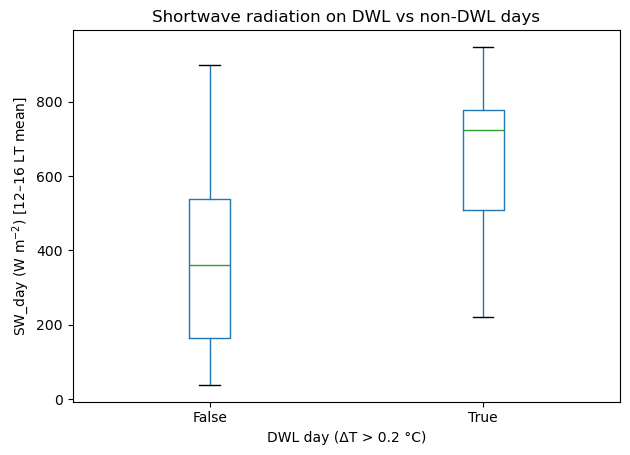

In [54]:
# make SW_day a TIME series for align
day_dim_sw = SW_day.dims[0]
SW_day_ts = (SW_day
             .assign_coords(TIME=SW_day[day_dim_sw].astype("datetime64[ns]"))
             .swap_dims({day_dim_sw: "TIME"})
             .sortby("TIME"))

DWL_a, SW_a = xr.align(DWL_flag_obs, SW_day_ts, join="inner")
mask = np.isfinite(DWL_a.values) & np.isfinite(SW_a.values)

df_sw = pd.DataFrame({
    "SW_day": SW_a.values[mask],
    "DWL":    DWL_a.values[mask].astype(bool)
})

plt.figure(figsize=(4.8,4.8))
df_sw.boxplot(column="SW_day", by="DWL", grid=False)
plt.ylabel("SW_day (W m$^{-2}$) [12–16 LT mean]")
plt.xlabel("DWL day (ΔT > 0.2 °C)")
plt.title("Shortwave radiation on DWL vs non-DWL days")
plt.suptitle("")
plt.tight_layout()
plt.show()


Part B — Regional model (ACCESS-OM3 regional)

In [16]:
root_dir = "/g/data/jk72/mxr581/SOTS-project-data/regional-model-output"
run_dirs = ["output009", "output010", "output011", "output012"]

fname_temp = "access-om3.mom6.region.3d.temp.z.1day.mean._2170.nc"
fname_surf = "access-om3.mom6.2d.1day.mean._2170.nc"

temp_paths = [os.path.join(root_dir, r, fname_temp) for r in run_dirs]
surf_paths = [os.path.join(root_dir, r, fname_surf) for r in run_dirs]

ds_temp_9m = xr.concat([xr.open_dataset(p) for p in temp_paths], dim="time")
ds_surf_9m = xr.concat([xr.open_dataset(p) for p in surf_paths], dim="time")

t_model = ds_temp_9m.time
print("Model time:", t_model.values[0], "->", t_model.values[-1], "N=", t_model.size)


/jobfs/157755023.gadi-pbs/ipykernel_249151/1233315316.py:10: FutureWarning: In a future version, xarray will not decode the variable 'average_DT' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_temp_9m = xr.concat([xr.open_dataset(p) for p in temp_paths], dim="time")
/jobfs/157755023.gadi-pbs/ipykernel_249151/1233315316.py:10: FutureWarning: In a future version, xarray will not decode the variable 'average_DT' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 

Model time: 2170-01-01 12:00:00 -> 2170-12-31 12:00:00 N= 365


In [17]:
sw_path  = "/g/data/vk83/configurations/inputs/JRA-55/RYF/v1-6/data/RYF.rsds.1990_1991.nc"
u_path   = "/g/data/vk83/configurations/inputs/JRA-55/RYF/v1-6/data/RYF.uas.1990_1991.nc"
v_path   = "/g/data/vk83/configurations/inputs/JRA-55/RYF/v1-6/data/RYF.vas.1990_1991.nc"

sots_lat = -47.0
sots_lon = 142.0

ds_sw  = xr.open_dataset(sw_path)
ds_u10 = xr.open_dataset(u_path)
ds_v10 = xr.open_dataset(v_path)

lat_name, lon_name = "lat", "lon"
lon_val = wrap_lon(sots_lon, ds_sw[lon_name])

rsds_sots = ds_sw["rsds"].sel({lat_name: sots_lat, lon_name: lon_val}, method="nearest")
uas_sots  = ds_u10["uas"].sel({lat_name: sots_lat, lon_name: lon_val}, method="nearest")
vas_sots  = ds_v10["vas"].sel({lat_name: sots_lat, lon_name: lon_val}, method="nearest")
wspd_sots = np.sqrt(uas_sots**2 + vas_sots**2)

rsds_day = rsds_sots.resample(time="1D").mean()
wspd_day = wspd_sots.resample(time="1D").mean()

# DOY mapping (1..365)
doy_model = xr.DataArray(np.arange(1, t_model.size + 1), coords={"time": t_model}, dims="time")
doy_force = rsds_day["time"].dt.dayofyear

rsds_by_doy = rsds_day.assign_coords(doy=doy_force).swap_dims({"time":"doy"}).drop_vars("time")
wspd_by_doy = wspd_day.assign_coords(doy=doy_force).swap_dims({"time":"doy"}).drop_vars("time")

rsds_on_model = rsds_by_doy.sel(doy=doy_model.values).rename(doy="time").assign_coords(time=t_model)
wspd_on_model = wspd_by_doy.sel(doy=doy_model.values).rename(doy="time").assign_coords(time=t_model)


Fig 10: JRA55 RYF rsds (daily) mapped to model time

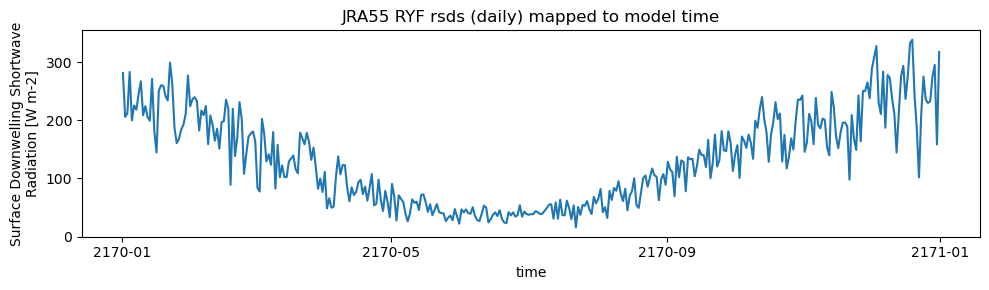

In [19]:
plt.figure(figsize=(10,3))
rsds_on_model.plot()
plt.title("JRA55 RYF rsds (daily) mapped to model time")
plt.tight_layout()
plt.show()


Fig 11: JRA55 RYF wind speed (daily) mapped to model time

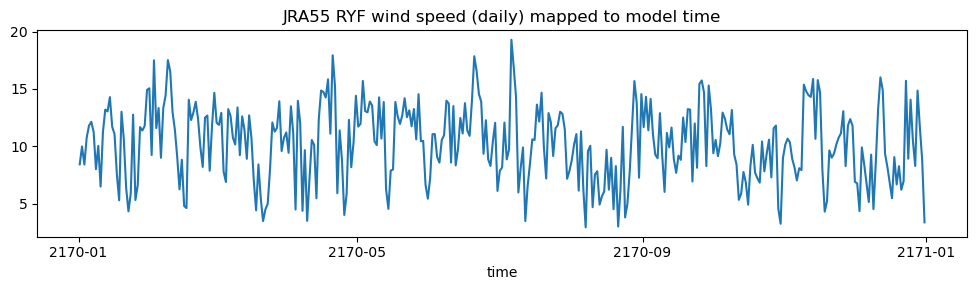

In [21]:
plt.figure(figsize=(10,3))
wspd_on_model.plot()
plt.title("JRA55 RYF wind speed (daily) mapped to model time")
plt.tight_layout()
plt.show()


Fig 12: Regional model: Monthly DWL-like occurrence (ΔT threshold proxy)

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

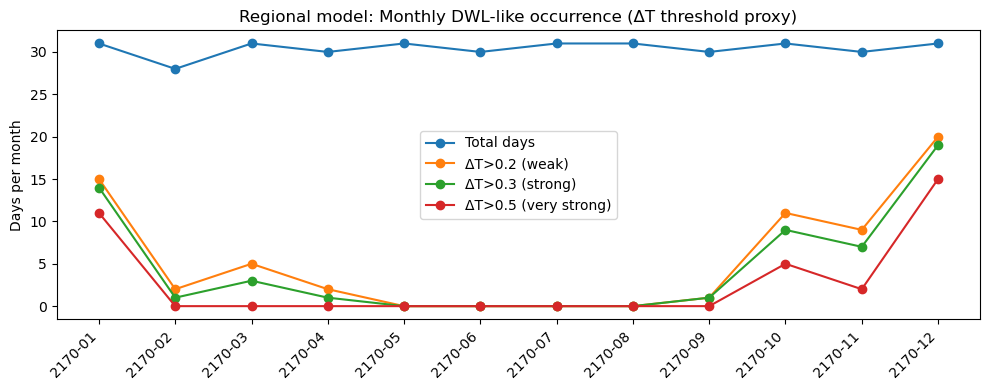

In [22]:
# SOTS point temp (daily mean)
temp_sots = ds_temp_9m["temp"].sel(yh_sub02=sots_lat, xh_sub02=sots_lon, method="nearest")

T_shallow = temp_sots.sel(z_l=slice(0,5)).mean("z_l", skipna=True)
T_deep    = temp_sots.sel(z_l=slice(20,30)).mean("z_l", skipna=True)

dT_mod = (T_shallow - T_deep).rename("dT_0_5_minus_20_30")

thr_weak, thr_strong, thr_vstrong = 0.2, 0.3, 0.5
flag02 = dT_mod > thr_weak
flag03 = dT_mod > thr_strong
flag05 = dT_mod > thr_vstrong

month_id = dT_mod["time"].dt.strftime("%Y-%m").rename("month")

total_days = dT_mod.groupby(month_id).count()
days02 = flag02.groupby(month_id).sum()
days03 = flag03.groupby(month_id).sum()
days05 = flag05.groupby(month_id).sum()

months = total_days["month"].values

plt.figure(figsize=(10,4))
plt.plot(months, total_days.values, marker="o", label="Total days")
plt.plot(months, days02.values, marker="o", label="ΔT>0.2 (weak)")
plt.plot(months, days03.values, marker="o", label="ΔT>0.3 (strong)")
plt.plot(months, days05.values, marker="o", label="ΔT>0.5 (very strong)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Days per month")
plt.title("Regional model: Monthly DWL-like occurrence (ΔT threshold proxy)")
plt.legend()
plt.tight_layout()
plt.show()


Fig 13: Stratification vs atmospheric forcing (SOTS point)

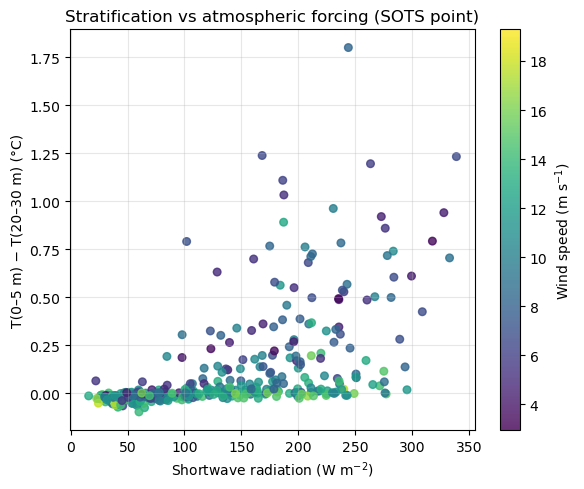

In [24]:
plt.figure(figsize=(6,5))
sc = plt.scatter(
    rsds_on_model.values,
    dT_mod.values,
    c=wspd_on_model.values,
    s=30,
    alpha=0.8
)
plt.colorbar(sc, label="Wind speed (m s$^{-1}$)")
plt.xlabel("Shortwave radiation (W m$^{-2}$)")
plt.ylabel("T(0–5 m) − T(20–30 m) (°C)")
plt.title("Stratification vs atmospheric forcing (SOTS point)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Fig 14: Double plot: “SW” and “Wind” (DWL-like vs non-DWL-like)

/jobfs/157755023.gadi-pbs/ipykernel_249151/2194654966.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([sw_nodwl.values, sw_dwl.values], labels=["No DWL", "DWL"], showfliers=False)
/jobfs/157755023.gadi-pbs/ipykernel_249151/2194654966.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([w_nodwl.values, w_dwl.values], labels=["No DWL", "DWL"], showfliers=False)


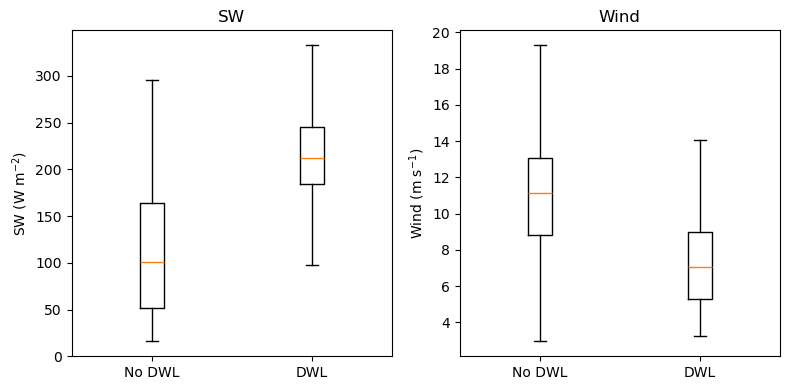

In [26]:
dwl_days = (dT_mod > 0.2)

sw_dwl   = rsds_on_model.where(dwl_days, drop=True)
sw_nodwl = rsds_on_model.where(~dwl_days, drop=True)

w_dwl    = wspd_on_model.where(dwl_days, drop=True)
w_nodwl  = wspd_on_model.where(~dwl_days, drop=True)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.boxplot([sw_nodwl.values, sw_dwl.values], labels=["No DWL", "DWL"], showfliers=False)
plt.ylabel("SW (W m$^{-2}$)")
plt.title("SW")

plt.subplot(1,2,2)
plt.boxplot([w_nodwl.values, w_dwl.values], labels=["No DWL", "DWL"], showfliers=False)
plt.ylabel("Wind (m s$^{-1}$)")
plt.title("Wind")

plt.tight_layout()
plt.show()
